# Evaluation Notebook

Loads a trained run from a specified directory, rebuilds the agents and simulation environment from the saved config, runs a single greedy simulation (ε=0), and plots performance metrics.

In [91]:
# ── Training run to evaluate ──────────────────────────────────────────────────
# Change this path to any run directory under training_results/
TRAINING_DIR = "training_results/run_20260328_183817"

In [92]:
import sys
import json
import pickle
import random
from pathlib import Path
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import yaml

sys.path.insert(0, str(Path(".").resolve()))

from simulator.application import Application
from simulator.infrastructure import Node
from simulator.simulation import Simulation
from agents.agents import QLearningAgent

## Load training artifacts

In [93]:
training_dir = Path(TRAINING_DIR)

with open(training_dir / "config.yaml") as f:
    config = yaml.safe_load(f)

with open(training_dir / "metadata.json") as f:
    metadata = json.load(f)

with open(training_dir / "qtables.pkl", "rb") as f:
    qtables = pickle.load(f)

print(f"Run         : {metadata['created_at']}")
print(f"Episodes    : {metadata['training']['n_episodes']}")
print(f"Best reward : {metadata['training']['best_episode_reward']:.2f}")
print(f"Final reward: {metadata['training']['final_episode_reward']:.2f}")
if metadata["training"].get("best_greedy_success_rate") is not None:
    print(f"Best greedy : {metadata['training']['best_greedy_success_rate']:.1f}%")
print(f"\nAgents ({len(qtables)}):")
for name, qt in qtables.items():
    print(f"  {name}: {len(qt)} Q-table states")

Run         : 20260328_183817
Episodes    : 1000
Best reward : 4.86
Final reward: 3.07
Best greedy : 85.4%

Agents (1):
  agent1: 1291 Q-table states


## Rebuild application and infrastructure from config

In [94]:
APP_TOPOLOGY = config.get("topology", {})
for wf in APP_TOPOLOGY.get("workflows", []):
    wf["edges"] = [tuple(e) for e in wf.get("edges", [])]

infra_cfg = config.get("infrastructure", {})
N_NODES  = infra_cfg.get("n_nodes", 3)
CPU_MAX  = infra_cfg.get("cpu_max", 4)
RAM      = infra_cfg.get("ram", 8)
FREQ     = infra_cfg.get("freq", 1000)

sim_cfg = config.get("simulation", {})
ITERATIONS    = sim_cfg.get("iterations", 500)
TIMEOUT       = sim_cfg.get("timeout", 600000)
EVAL_INTERVAL = sim_cfg.get("eval_interval", 10.0)
SEED          = sim_cfg.get("seed", 42)

rl_cfg = config.get("rl", {})
ALPHA  = rl_cfg.get("alpha", 0.1)
GAMMA  = rl_cfg.get("gamma", 0.9)

ctrl_cfg = config.get("control", {})
AGENT_CONTROLS_REPLICAS   = ctrl_cfg.get("agent_controls_replicas", True)
AGENT_CONTROLS_PLACEMENT  = ctrl_cfg.get("agent_controls_placement", False)
AGENT_CONTROL_ASSIGNMENTS = ctrl_cfg.get("agent_control_assignments", {})

reward_cfg = config.get("reward", {})
E2E_LAT_TARGET    = reward_cfg.get("e2e_lat_target", 4.0)
REWARD_CPU_WEIGHT = reward_cfg.get("reward_cpu_weight", 0.5)
REWARD_LAT_WEIGHT = reward_cfg.get("reward_lat_viol_weight", 0.5)

np.random.seed(SEED)
random.seed(SEED)

app   = Application(topology=APP_TOPOLOGY)
nodes = [Node(i, CPU_MAX, RAM, FREQ) for i in range(N_NODES)]

initial_service_map = {s.id: nodes[s.id % N_NODES] for s in app.services}
app.deploy_services(initial_service_map)
for s in app.services:
    s.threads = CPU_MAX
app.reset()

service_ids = [s.id for s in app.services]

print(f"Services : {len(app.services)}")
print(f"Workflows: {len(app.workflows)}")
for s in app.services:
    print(f"  s{s.id} -> node {s.node.id}  threads={s.threads}")

Services: 4
Tasktrees: 2
[0, 1]
[2, 3]
Labels: {0: 0, 1: 1, 2: 2, 3: 3}
Services : 4
Workflows: 2
  s0 -> node 0  threads=4
  s1 -> node 1  threads=4
  s2 -> node 2  threads=4
  s3 -> node 0  threads=4


## Rebuild agents and load saved Q-tables (ε=0)

In [95]:
def _normalize_control(name):
    n = str(name).strip().lower()
    if n in ("scaling", "replicas", "cpu"):
        return "cpu"
    if n in ("migration", "placement", "node"):
        return "node"
    raise ValueError(f"Unknown control: {name}")


def _parse_service_token(token, sids):
    raw = int(str(token).strip().lower().lstrip("s"))
    if 0 in sids and (raw - 1) in sids:
        return raw - 1
    return raw if raw in sids else raw - 1


def _build_action_space(responsibilities, node_pool, cpu_actions):
    dims = [(sid, ctrl, list(cpu_actions) if ctrl == "cpu" else list(node_pool))
            for sid, ctrl in responsibilities]
    if not dims:
        return [{}]
    space = []
    for combo in product(*[opts for _, _, opts in dims]):
        action = {}
        for (sid, ctrl, _), val in zip(dims, combo):
            action.setdefault(sid, {})[ctrl] = val
        space.append(action)
    return space


def _make_get_state(responsibilities, cpu_cap=20):
    scope = sorted({sid for sid, _ in responsibilities})
    def _get_state(self, obs):
        queues = obs.get("service_queues", [])
        cpus   = obs.get("service_cpus", [])
        state  = []
        for sid in scope:
            q = int(queues[sid])
            state.append(0 if q == 0 else 1 if q <= 4 else 2)
        for sid in scope:
            state.append(min(int(cpus[sid]), cpu_cap))
        return tuple(state)
    return _get_state


def _make_reward(responsibilities, workflow_scope):
    scope   = sorted({sid for sid, _ in responsibilities})
    total_w = REWARD_CPU_WEIGHT + REWARD_LAT_WEIGHT
    cpu_w   = REWARD_CPU_WEIGHT / total_w if total_w > 0 else 0.5
    lat_w   = REWARD_LAT_WEIGHT / total_w if total_w > 0 else 0.5
    lat_tgt = max(float(E2E_LAT_TARGET), 1e-12)
    def _reward(self, obs):
        viol_rates = obs.get("workflow_violation_rates", [])
        e2e_means  = obs.get("workflow_e2e_means", [])
        node_ids   = obs.get("service_node_ids", [])
        node_cpu   = obs.get("node_cpu_usage_pct", {})
        lat_viols  = []
        for wid in workflow_scope:
            if wid < len(viol_rates):
                lat_viols.append(min(1.0, max(0.0, float(viol_rates[wid]))))
            else:
                e2e = float(e2e_means[wid]) if wid < len(e2e_means) else 0.0
                lat_viols.append(min(1.0, max(0.0, (e2e - lat_tgt) / lat_tgt)))
        mean_lat = float(np.mean(lat_viols)) if lat_viols else 0.0
        nscope = sorted({node_ids[sid] for sid in scope}) if scope else []
        mean_cpu = float(np.mean([min(1.0, max(0.0, float(node_cpu.get(nid, 0.0)))) for nid in nscope])) if nscope else 0.0
        return 1.0 - (cpu_w * mean_cpu + lat_w * mean_lat)
    return _reward


# ── Build agent specs from config ─────────────────────────────────────────────
service_to_wf = {}
for wf in app.workflows:
    for task_node in wf.nodes:
        sid = int(app.task_graph.nodes[task_node]["subset"])
        service_to_wf.setdefault(sid, set()).add(wf.id)
service_to_wf = {k: sorted(v) for k, v in service_to_wf.items()}

by_agent = {}
for key, agent_name in AGENT_CONTROL_ASSIGNMENTS.items():
    parts = str(key).split(".", 1)
    sid   = _parse_service_token(parts[0], service_ids)
    ctrl  = _normalize_control(parts[1])
    by_agent.setdefault(str(agent_name).strip(), set()).add((sid, ctrl))

agent_specs = []
for aname in sorted(by_agent.keys()):
    resp         = sorted(by_agent[aname])
    action_space = _build_action_space(resp, [n.id for n in nodes], range(1, CPU_MAX + 1))
    s_scope      = {sid for sid, _ in resp}
    wf_scope     = sorted({wid for sid in s_scope for wid in service_to_wf.get(sid, [])})
    agent_specs.append({"name": aname, "responsibilities": resp,
                         "action_space": action_space, "workflow_scope": wf_scope})

# ── Instantiate agents with epsilon=0 and load Q-tables ───────────────────────
global_agents = []
for spec in agent_specs:
    agent = QLearningAgent(epsilon=0.0, alpha=ALPHA, gamma=GAMMA,
                           actions=list(range(len(spec["action_space"]))))
    agent.get_state = _make_get_state(spec["responsibilities"]).__get__(agent, QLearningAgent)
    agent.reward    = _make_reward(spec["responsibilities"], spec["workflow_scope"]).__get__(agent, QLearningAgent)
    if spec["name"] in qtables:
        agent.q_table = qtables[spec["name"]]
        print(f"  {spec['name']}: loaded Q-table ({len(agent.q_table)} states)")
    else:
        print(f"  WARNING: no saved Q-table for agent '{spec['name']}'")
    global_agents.append({
        "name": spec["name"], "responsibilities": spec["responsibilities"],
        "workflow_scope": spec["workflow_scope"],
        "action_space": spec["action_space"], "agent": agent,
    })

  agent1: loaded Q-table (1291 states)


## Evaluation dispatcher with metrics capture

In [96]:
class EvalDispatcher:
    """Greedy dispatcher (epsilon=0) that records per-eval-window metrics."""

    def __init__(self, service_ids, global_agents, nodes, cpu_max):
        self.service_ids   = list(service_ids)
        self.global_agents = global_agents
        self.nodes         = nodes
        self.cpu_max       = cpu_max
        self._reset_state()

    def _reset_state(self):
        self._eval_counter            = 0
        self._planned_actions         = {}
        self._last_node_metric_idx    = {n.id: 0 for n in self.nodes}
        self._sim_time                = 0.0
        self.eval_times               = []
        self.svc_queue_hist           = {sid: [] for sid in self.service_ids}
        self.svc_thread_hist          = {sid: [] for sid in self.service_ids}
        self.svc_running_hist         = {sid: [] for sid in self.service_ids}
        self.wf_violation_hist        = {}
        self.wf_latency_hist          = {}
        self.wf_success_hist          = {}
        self.node_cpu_hist            = {n.id: [] for n in self.nodes}
        self.agent_reward_hist        = {item["name"]: [] for item in self.global_agents}
        for item in self.global_agents:
            item["agent"].reset_environment()

    def _build_observations(self, accumulated, instant):
        svc_now  = instant["services"]
        queues   = [s["queue_size"] for s in svc_now]
        threads  = [s["threads"]    for s in svc_now]
        node_ids = [s["node_id"]    for s in svc_now]
        node_cpu_pct = {}
        for node in self.nodes:
            arr   = np.array(node.cpu_metric, dtype=float)
            start = int(self._last_node_metric_idx.get(node.id, 0))
            seg   = arr[start:] if start < arr.size else np.array([], dtype=float)
            avg   = float(np.mean(seg)) if seg.size > 0 else 0.0
            node_cpu_pct[node.id] = min(1.0, max(0.0, avg / max(self.cpu_max, 1e-12)))
            self._last_node_metric_idx[node.id] = arr.size
        return {
            "service_queues"          : queues,
            "service_cpus"            : threads,
            "service_node_ids"        : node_ids,
            "workflow_e2e_means"      : accumulated["workflows"].get("e2e_latencies", []),
            "workflow_violation_rates": accumulated["workflows"].get("violation_rates", []),
            "node_cpu_usage_pct"      : node_cpu_pct,
            "avg_success_rate"        : accumulated["workflows"]["avg_success_rate"],
        }

    def _capture(self, accumulated, instant, obs):
        self._sim_time += float(accumulated.get("elapsed", 0.0))
        self.eval_times.append(self._sim_time)
        for s_info in instant["services"]:
            sid = s_info["service_id"]
            self.svc_queue_hist[sid].append(s_info["queue_size"])
            self.svc_thread_hist[sid].append(s_info["threads"])
            self.svc_running_hist[sid].append(s_info["running_tasks"])
        viol_list = accumulated["workflows"].get("violation_rates", [])
        lat_list  = accumulated["workflows"].get("e2e_latencies", [])
        sr_list   = accumulated["workflows"].get("success_rate", [])
        for wid, (vr, lat, sr) in enumerate(zip(viol_list, lat_list, sr_list)):
            self.wf_violation_hist.setdefault(wid, []).append(vr * 100.0)
            self.wf_latency_hist.setdefault(wid, []).append(lat)
            self.wf_success_hist.setdefault(wid, []).append(sr)
        for nid, pct in obs["node_cpu_usage_pct"].items():
            self.node_cpu_hist[nid].append(pct * 100.0)
        for item in self.global_agents:
            r = item["agent"].rewards[-1] if item["agent"].rewards else 0.0
            self.agent_reward_hist[item["name"]].append(r)

    def _compute_plan(self, accumulated, instant):
        obs      = self._build_observations(accumulated, instant)
        combined = {sid: {} for sid in self.service_ids}
        for item in self.global_agents:
            idx = int(item["agent"].step(obs))
            idx = max(0, min(idx, len(item["action_space"]) - 1))
            for sid, act in item["action_space"][idx].items():
                combined[sid].update(act)
        self._planned_actions = combined
        self._capture(accumulated, instant, obs)

    def on_eval(self, service_idx, service, accumulated, instant):
        if self._eval_counter % len(self.service_ids) == 0:
            self._compute_plan(accumulated, instant)
        self._eval_counter += 1
        action = self._planned_actions.get(service.id, {})
        return action if action else None

## Run simulation

In [97]:
# ── Reset environment ─────────────────────────────────────────────────────────
for s in app.services:
    s.node    = initial_service_map[s.id]
    s.threads = CPU_MAX
app.reset()
for node in nodes:
    node.reset()

# ── Create dispatcher ─────────────────────────────────────────────────────────
dispatcher  = EvalDispatcher(service_ids, global_agents, nodes, CPU_MAX)
dispatchers = {sid: dispatcher for sid in service_ids}

# ── Run ───────────────────────────────────────────────────────────────────────
sim = Simulation(
    [app], [],
    ITERATIONS,
    step_size=ITERATIONS,
    alloc_step_size=1,
    timeout=TIMEOUT,
    eval_interval=EVAL_INTERVAL,
    latency_target=E2E_LAT_TARGET,
)
sim.run(agents=dispatchers)

print(f"Simulation ended at t={sim.t:.1f}s  |  {len(sim.history)} traces")

Simulation ended at t=67.0s  |  154 traces


## Process simulation history

In [98]:
task_to_wf   = {}
for wf in app.workflows:
    for tid in wf.nodes:
        task_to_wf[int(tid)] = int(wf.id)

wf_root_task = {int(wf.id): int(wf.initial_task.id) for wf in app.workflows}

per_wf_arrivals   = {wf.id: [] for wf in app.workflows}
per_wf_latencies  = {wf.id: [] for wf in app.workflows}
per_wf_violations = {wf.id: [] for wf in app.workflows}
total_req = total_viol = total_timeout = 0

for trace_data in sim.history.values():
    status    = int(trace_data.get("status", -1))
    task_keys = [k for k in trace_data if k != "status"]
    if not task_keys:
        continue
    wf_id = next((task_to_wf.get(int(k)) for k in task_keys
                  if task_to_wf.get(int(k)) is not None), None)
    if wf_id is None:
        continue
    root_times = trace_data.get(wf_root_task.get(wf_id))
    if root_times is None or len(root_times) < 2:
        continue
    arrival = float(root_times[0])
    per_wf_arrivals[wf_id].append(arrival)
    if status == 1:
        e2e      = float(root_times[-1] - root_times[0])
        violated = e2e > E2E_LAT_TARGET
        per_wf_latencies[wf_id].append(e2e)
        per_wf_violations[wf_id].append(int(violated))
        total_req  += 1
        total_viol += int(violated)
    elif status == 2:
        total_timeout += 1

completed = sum(1 for v in sim.history.values() if v.get("status") == 1)
total_tr  = len(sim.history)

print(f"Total requests : {total_tr}")
print(f"Completed      : {completed}  ({100*completed/max(total_tr,1):.1f}%)")
print(f"Timeouts       : {total_timeout}  ({100*total_timeout/max(total_tr,1):.1f}%)")
print(f"SLA violations : {total_viol}  ({100*total_viol/max(total_req,1):.1f}% of completed)")
print()
for wf in app.workflows:
    lats  = per_wf_latencies[wf.id]
    viols = per_wf_violations[wf.id]
    if lats:
        print(f"  Workflow {wf.id}: {len(lats)} completed  "
              f"avg={np.mean(lats):.3f}s  p95={np.percentile(lats, 95):.3f}s  "
              f"violations={sum(viols)} ({100*np.mean(viols):.1f}%)")
    else:
        print(f"  Workflow {wf.id}: 0 completed")

Total requests : 154
Completed      : 111  (72.1%)
Timeouts       : 0  (0.0%)
SLA violations : 67  (60.4% of completed)

  Workflow 0: 61 completed  avg=11.430s  p95=19.743s  violations=46 (75.4%)
  Workflow 1: 50 completed  avg=7.037s  p95=12.237s  violations=21 (42.0%)


## Plots

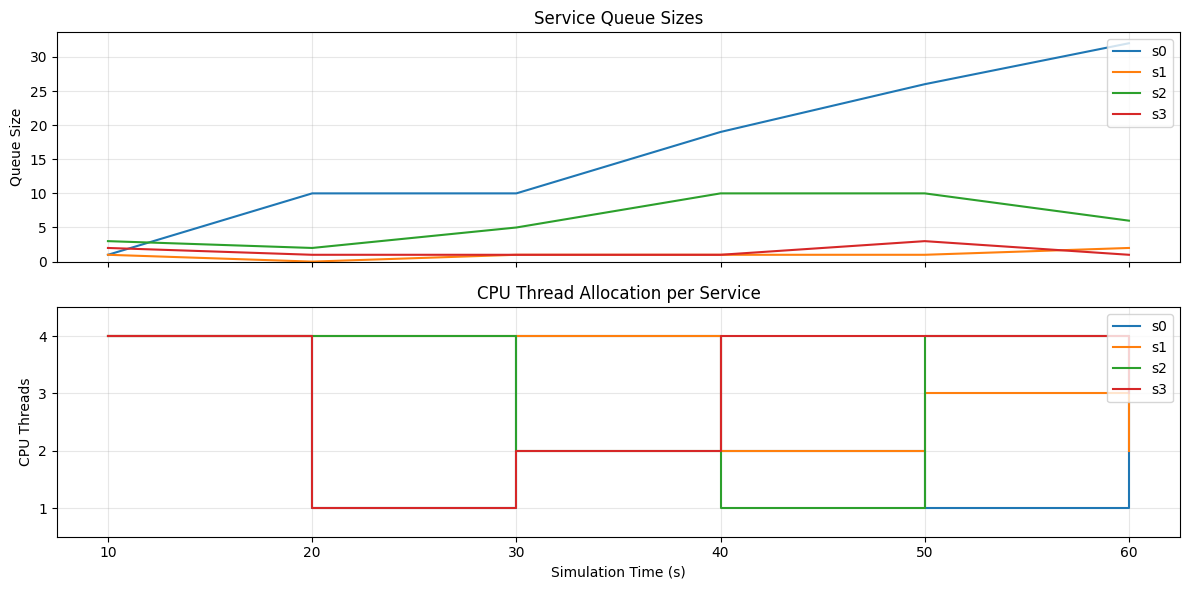

In [99]:
# ── Plot 1: Service queue size and thread allocation over simulation time ──────
t_axis = dispatcher.eval_times
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, sid in enumerate(sorted(dispatcher.svc_queue_hist)):
    axes[0].plot(t_axis, dispatcher.svc_queue_hist[sid],
                 color=colors[i % len(colors)], label=f"s{sid}", linewidth=1.5)
    axes[1].plot(t_axis, dispatcher.svc_thread_hist[sid],
                 color=colors[i % len(colors)], label=f"s{sid}",
                 linewidth=1.5, drawstyle="steps-post")

axes[0].set_ylabel("Queue Size")
axes[0].set_title("Service Queue Sizes")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

axes[1].set_ylabel("CPU Threads")
axes[1].set_title("CPU Thread Allocation per Service")
axes[1].set_xlabel("Simulation Time (s)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, CPU_MAX + 0.5)
axes[1].set_yticks(range(1, CPU_MAX + 1))

plt.tight_layout()
plt.show()

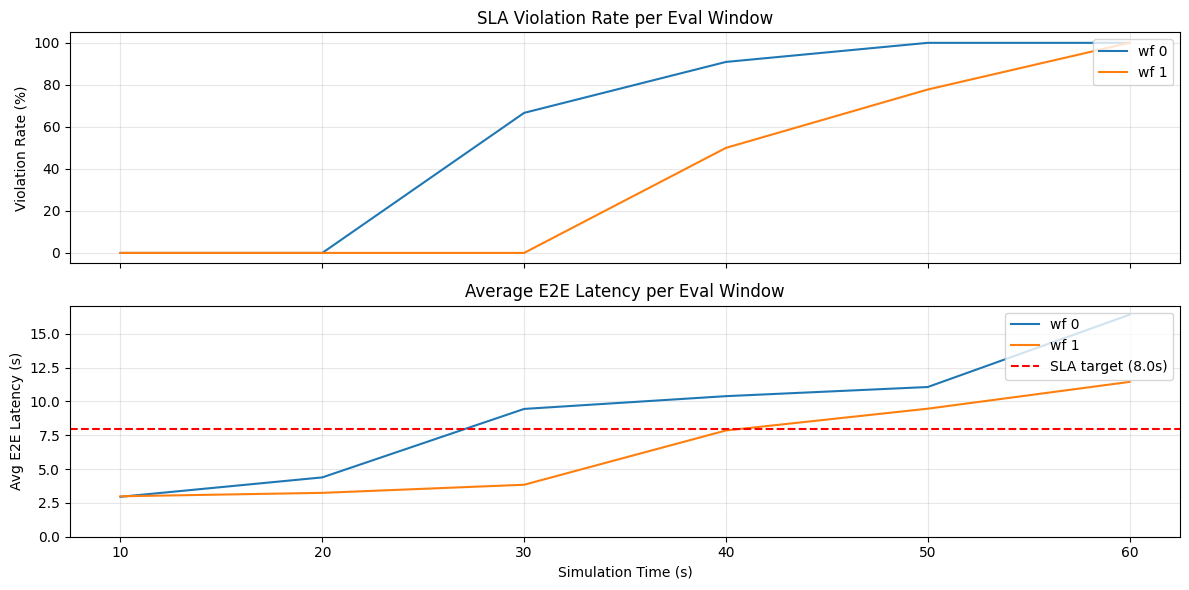

In [100]:
# ── Plot 2: Per-workflow violation rate and avg e2e latency per eval window ────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for wid in range(len(app.workflows)):
    if wid not in dispatcher.wf_violation_hist:
        continue
    c = colors[wid % len(colors)]
    axes[0].plot(t_axis, dispatcher.wf_violation_hist[wid],
                 color=c, label=f"wf {wid}", linewidth=1.5)
    axes[1].plot(t_axis, dispatcher.wf_latency_hist[wid],
                 color=c, label=f"wf {wid}", linewidth=1.5)

axes[0].set_ylabel("Violation Rate (%)")
axes[0].set_title("SLA Violation Rate per Eval Window")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-5, 105)

axes[1].axhline(E2E_LAT_TARGET, color="red", linestyle="--",
                linewidth=1.5, label=f"SLA target ({E2E_LAT_TARGET}s)")
axes[1].set_ylabel("Avg E2E Latency (s)")
axes[1].set_title("Average E2E Latency per Eval Window")
axes[1].set_xlabel("Simulation Time (s)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

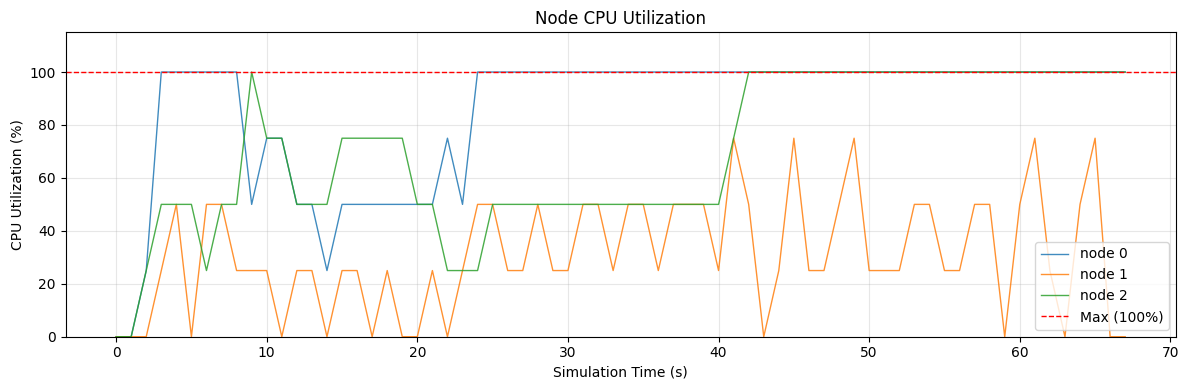

In [101]:
# ── Plot 3: Node CPU utilization at 1-second resolution ───────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for node in nodes:
    cpu_arr = np.array(node.cpu_metric, dtype=float)
    t_sec   = np.arange(len(cpu_arr))
    pct     = 100.0 * cpu_arr / max(CPU_MAX, 1e-12)
    ax.plot(t_sec, pct, color=colors[node.id % len(colors)],
            label=f"node {node.id}", linewidth=1.0, alpha=0.85)

ax.axhline(100.0, color="red", linestyle="--", linewidth=1.0, label="Max (100%)")
ax.set_xlabel("Simulation Time (s)")
ax.set_ylabel("CPU Utilization (%)")
ax.set_title("Node CPU Utilization")
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

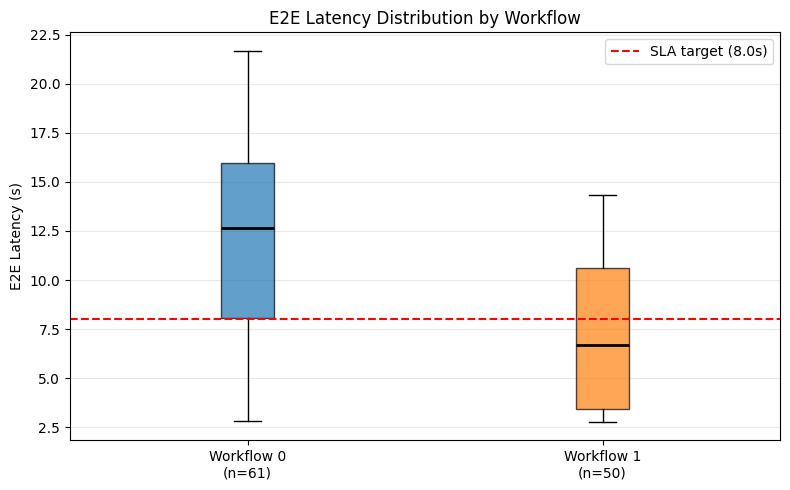

In [102]:
# ── Plot 4: E2E latency distribution per workflow ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = []
labels       = []
for wf in app.workflows:
    lats = per_wf_latencies[wf.id]
    if lats:
        data_to_plot.append(lats)
        labels.append(f"Workflow {wf.id}\n(n={len(lats)})")

if data_to_plot:
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(E2E_LAT_TARGET, color="red", linestyle="--",
               linewidth=1.5, label=f"SLA target ({E2E_LAT_TARGET}s)")
    ax.set_ylabel("E2E Latency (s)")
    ax.set_title("E2E Latency Distribution by Workflow")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
else:
    ax.text(0.5, 0.5, "No completed requests",
            ha="center", va="center", transform=ax.transAxes, fontsize=14)

plt.tight_layout()
plt.show()

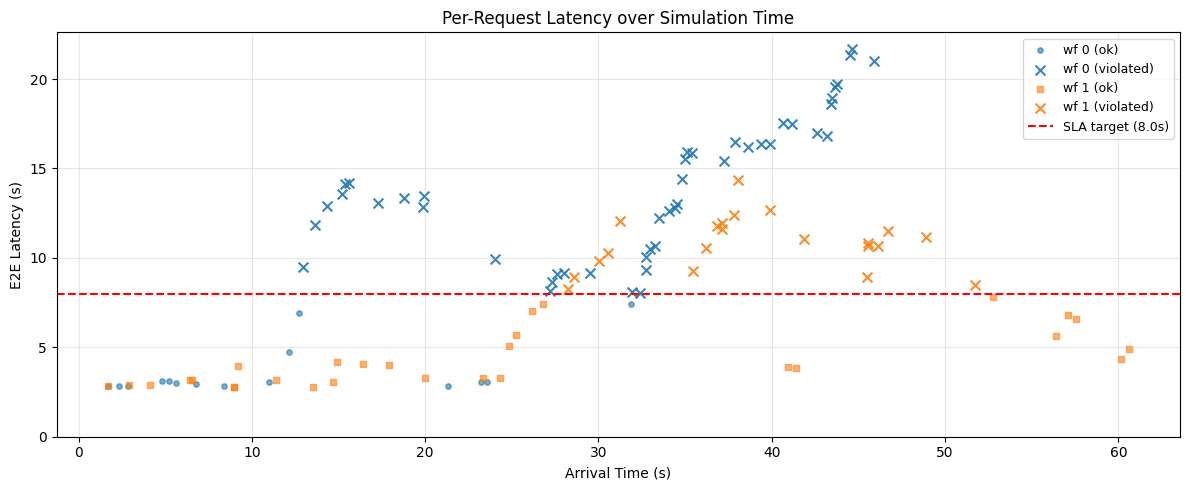

In [103]:
# ── Plot 5: Per-request latency vs arrival time ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
markers = ["o", "s", "^", "D", "v", "P"]

for wf in app.workflows:
    lats     = per_wf_latencies[wf.id]
    arrivals = per_wf_arrivals[wf.id][:len(lats)]
    viols    = per_wf_violations[wf.id]
    if not lats:
        continue
    c = colors[wf.id % len(colors)]
    m = markers[wf.id % len(markers)]
    ok_t = [arrivals[i] for i, v in enumerate(viols) if not v]
    ok_l = [lats[i]     for i, v in enumerate(viols) if not v]
    vl_t = [arrivals[i] for i, v in enumerate(viols) if v]
    vl_l = [lats[i]     for i, v in enumerate(viols) if v]
    ax.scatter(ok_t, ok_l, color=c, marker=m, s=15, alpha=0.6,
               label=f"wf {wf.id} (ok)")
    if vl_t:
        ax.scatter(vl_t, vl_l, color=c, marker="x", s=50, alpha=0.9,
                   linewidths=1.5, label=f"wf {wf.id} (violated)")

ax.axhline(E2E_LAT_TARGET, color="red", linestyle="--",
           linewidth=1.5, label=f"SLA target ({E2E_LAT_TARGET}s)")
ax.set_xlabel("Arrival Time (s)")
ax.set_ylabel("E2E Latency (s)")
ax.set_title("Per-Request Latency over Simulation Time")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

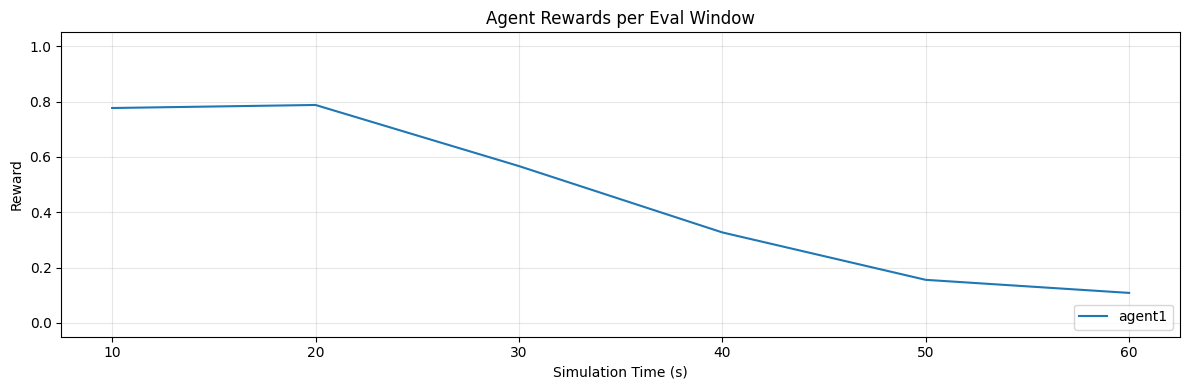

In [104]:
# ── Plot 6: Agent rewards over simulation time ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for i, (name, rewards) in enumerate(dispatcher.agent_reward_hist.items()):
    ax.plot(t_axis, rewards, color=colors[i % len(colors)],
            label=name, linewidth=1.5)

ax.set_xlabel("Simulation Time (s)")
ax.set_ylabel("Reward")
ax.set_title("Agent Rewards per Eval Window")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [105]:
sep = "=" * 60
print(sep)
print(f"  Run              : {metadata['created_at']}")
print(f"  Training episodes: {metadata['training']['n_episodes']}")
print(f"  Best train reward: {metadata['training']['best_episode_reward']:.2f}")
print(sep)
print(f"  Simulation results (greedy, epsilon=0):")
print(f"    Total requests  : {total_tr}")
print(f"    Completed       : {completed} ({100*completed/max(total_tr,1):.1f}%)")
print(f"    Timeouts        : {total_timeout}")
print(f"    SLA violations  : {total_viol} ({100*total_viol/max(total_req,1):.1f}% of completed)")
print()
for wf in app.workflows:
    lats  = per_wf_latencies[wf.id]
    viols = per_wf_violations[wf.id]
    print(f"    Workflow {wf.id}:")
    if lats:
        print(f"      Completed   : {len(lats)}")
        print(f"      Avg latency : {np.mean(lats):.3f}s")
        print(f"      P50 latency : {np.median(lats):.3f}s")
        print(f"      P95 latency : {np.percentile(lats, 95):.3f}s")
        print(f"      Violations  : {sum(viols)} ({100*np.mean(viols):.1f}%)")
    else:
        print(f"      No completed requests")
print()
for item in global_agents:
    rwds = dispatcher.agent_reward_hist.get(item["name"], [])
    if rwds:
        print(f"    Agent {item['name']} avg reward: {np.mean(rwds):.3f}")
print(sep)

  Run              : 20260328_183817
  Training episodes: 1000
  Best train reward: 4.86
  Simulation results (greedy, epsilon=0):
    Total requests  : 154
    Completed       : 111 (72.1%)
    Timeouts        : 0
    SLA violations  : 67 (60.4% of completed)

    Workflow 0:
      Completed   : 61
      Avg latency : 11.430s
      P50 latency : 12.636s
      P95 latency : 19.743s
      Violations  : 46 (75.4%)
    Workflow 1:
      Completed   : 50
      Avg latency : 7.037s
      P50 latency : 6.704s
      P95 latency : 12.237s
      Violations  : 21 (42.0%)

    Agent agent1 avg reward: 0.454
